In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.width', 160)
OUT_DIR = 'outputs'; FIG_DIR = 'outputs/figures'; os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng(0)

d = pd.read_parquet(f'{OUT_DIR}/analytic_with_weights.parquet')
T = d['T'].values
SES    = ['revenu_ord', 'instruction_ord', 'wealth_index']
NONSES = ['age', 'mariee', 'agri_elevage', 'nb_grossesses', 'nb_enfants',
          'antecedent_complication', 'accouchement_dystocique']
print('Chargé :', d.shape)

Chargé : (654, 26)


In [3]:
for v, lab in [('cascade_score', 'Score cascade'), ('cascade_complete', 'Continuum complet')]:
    y = pd.to_numeric(d[v], errors='coerce')
    fat = y[(d['site'] == 'Fatick') & (T == 0)].mean()
    mix = y[(d['site'] != 'Fatick') & (T == 0)].mean()
    tr  = y[T == 1].mean()
    print('  %-18s témoins Fatick=%.3f | témoins mixtes=%.3f | assurées=%.3f' % (lab, fat, mix, tr))
print('\n-> témoins Fatick > témoins mixtes (et parfois > assurées) : ils masquent l\'effet.')

  Score cascade      témoins Fatick=3.544 | témoins mixtes=3.160 | assurées=3.416
  Continuum complet  témoins Fatick=0.663 | témoins mixtes=0.404 | assurées=0.544

-> témoins Fatick > témoins mixtes (et parfois > assurées) : ils masquent l'effet.


In [4]:
def weights_from(cols, use_site, data):
    parts = []
    if cols: parts.append(data[cols])
    if use_site: parts.append(pd.get_dummies(data['site'], drop_first=True))
    X = pd.concat(parts, axis=1).astype(float); Xz = StandardScaler().fit_transform(X)
    e = LogisticRegression(C=1.0, max_iter=3000).fit(Xz, data['T'].values).predict_proba(Xz)[:, 1]
    Tt = data['T'].values
    return np.where(Tt == 1, 1 - e, e)

def wdiff(y, Tt, w):
    m = ~np.isnan(y)
    return np.average(y[m & (Tt == 1)], weights=w[m & (Tt == 1)]) -            np.average(y[m & (Tt == 0)], weights=w[m & (Tt == 0)])

configs = [('Brut', None, False), ('Géographie seule', None, True),
           ('Socio-éco seul', SES, False), ('Ajustement complet', NONSES + SES, True)]
it, ic = np.where(T == 1)[0], np.where(T == 0)[0]; B = 400
rows = []; store = {}
for v, lab in [('cascade_score', 'Score de cascade'), ('cascade_complete', 'Continuum complet')]:
    y = pd.to_numeric(d[v], errors='coerce').astype(float).values
    sd = pd.to_numeric(d[v], errors='coerce').std()
    for name, cols, us in configs:
        pt = (y[T == 1].mean() - y[T == 0].mean()) if (cols is None and not us) else wdiff(y, T, weights_from(cols, us, d))
        bv = []
        for _ in range(B):
            bi = np.concatenate([rng.choice(it, len(it), True), rng.choice(ic, len(ic), True)]); db = d.iloc[bi]
            yb = pd.to_numeric(db[v], errors='coerce').astype(float).values; Tb = db['T'].values
            bv.append((yb[Tb == 1].mean() - yb[Tb == 0].mean()) if (cols is None and not us)
                      else wdiff(yb, Tb, weights_from(cols, us, db)))
        lo, hi = np.percentile(bv, [2.5, 97.5])
        rows.append((lab, name, round(pt, 3), round(lo, 3), round(hi, 3), '✓' if (lo > 0) == (hi > 0) else '—'))
        store[(v, name)] = (pt / sd, sorted([lo / sd, hi / sd]))
Rt = pd.DataFrame(rows, columns=['résultat', 'ajustement', 'effet', 'IC_bas', 'IC_haut', 'signif'])
print(Rt.to_string(index=False))

         résultat         ajustement  effet  IC_bas  IC_haut signif
 Score de cascade               Brut  0.056  -0.072    0.167      —
 Score de cascade   Géographie seule  0.268   0.111    0.418      ✓
 Score de cascade     Socio-éco seul  0.186   0.067    0.328      ✓
 Score de cascade Ajustement complet  0.305   0.173    0.465      ✓
Continuum complet               Brut  0.006  -0.065    0.082      —
Continuum complet   Géographie seule  0.159   0.066    0.256      ✓
Continuum complet     Socio-éco seul  0.089   0.009    0.167      ✓
Continuum complet Ajustement complet  0.184   0.095    0.277      ✓


In [5]:
M = d[d['site'] != 'Fatick'].reset_index(drop=True); Tm = M['T'].values
print('Sous-échantillon mixte : %d femmes (%d assurées / %d témoins)' %
      (len(M), (Tm == 1).sum(), (Tm == 0).sum()))
itm, icm = np.where(Tm == 1)[0], np.where(Tm == 0)[0]
CONF = NONSES + SES
for v, lab in [('cascade_score', 'Score cascade'), ('cascade_complete', 'Continuum complet')]:
    y = pd.to_numeric(M[v], errors='coerce').astype(float).values
    raw = y[Tm == 1].mean() - y[Tm == 0].mean()
    X = pd.concat([M[CONF], pd.get_dummies(M['site'], drop_first=True)], axis=1).astype(float)
    e = LogisticRegression(C=1.0, max_iter=3000).fit(StandardScaler().fit_transform(X), Tm).predict_proba(
        StandardScaler().fit_transform(X))[:, 1]
    wj = np.where(Tm == 1, 1 - e, e)
    adj = np.average(y[Tm == 1], weights=wj[Tm == 1]) - np.average(y[Tm == 0], weights=wj[Tm == 0])
    bv = []
    for _ in range(500):
        bi = np.concatenate([rng.choice(itm, len(itm), True), rng.choice(icm, len(icm), True)])
        bv.append(y[bi][Tm[bi] == 1].mean() - y[bi][Tm[bi] == 0].mean())
    lo, hi = np.percentile(bv, [2.5, 97.5])
    print('  %-18s BRUT (mixtes seuls)=%+.3f IC[%+.3f;%+.3f]  | AJUSTÉ=%+.3f  %s' %
          (lab, raw, lo, hi, adj, '✓' if (lo > 0) == (hi > 0) and lo > 0 else '—'))
print('\n-> l\'effet est présent DÈS le brut dans les zones comparables : le masquage est une')
print('   contamination réelle par Fatick, pas un artefact de pondération.')

Sous-échantillon mixte : 485 femmes (329 assurées / 156 témoins)
  Score cascade      BRUT (mixtes seuls)=+0.256 IC[+0.089;+0.406]  | AJUSTÉ=+0.307  ✓
  Continuum complet  BRUT (mixtes seuls)=+0.140 IC[+0.055;+0.231]  | AJUSTÉ=+0.186  ✓

-> l'effet est présent DÈS le brut dans les zones comparables : le masquage est une
   contamination réelle par Fatick, pas un artefact de pondération.


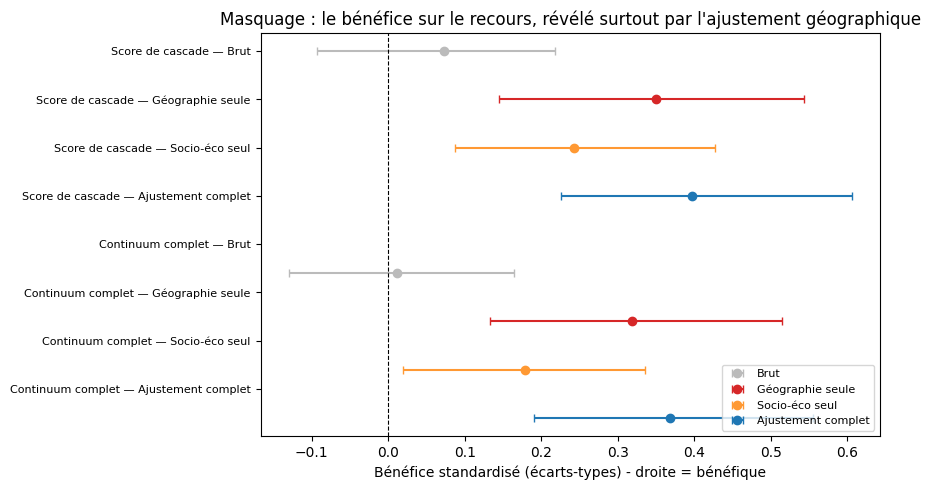

In [8]:
col = {'Brut': '#bbbbbb', 'Géographie seule': '#d62728', 'Socio-éco seul': '#ff9933', 'Ajustement complet': '#1f77b4'}
fig, ax = plt.subplots(figsize=(9, 5)); yv = 0; ylab = []
for v, lab in [('cascade_score', 'Score de cascade'), ('cascade_complete', 'Continuum complet')]:
    for name, _, _ in configs:
        b, (l, h) = store[(v, name)]
        ax.errorbar(b, yv, xerr=[[b - l], [h - b]], fmt='o', color=col[name], capsize=3,
                    label=name if yv < 4 else '')
        ylab.append(f'{lab} — {name}'); yv += 1
    yv += 0.6
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.set_yticks(range(len(ylab))); ax.set_yticklabels(ylab, fontsize=8)
ax.set_xlabel('Bénéfice standardisé (écarts-types) - droite = bénéfique')
ax.set_title('Masquage : le bénéfice sur le recours, révélé surtout par l\'ajustement géographique')
ax.invert_yaxis(); ax.legend(fontsize=8, loc='lower right'); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/masquage.png', dpi=150)
plt.show()

In [6]:
Rt.to_csv(f'{OUT_DIR}/masquage_decomposition.csv', index=False, encoding='utf-8-sig')
print('Sauvegardé : masquage_decomposition.csv, figure masquage.png')

Sauvegardé : masquage_decomposition.csv, figure masquage.png
